In [41]:
# Import Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [42]:
df_DA_DE = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Germany')].copy()

df_DA_DE = df_DA_DE.dropna(subset=['salary_year_avg'])

In [43]:
df_DA_DE = df_DA_DE.explode('job_skills')

df_DA_DE[['job_skills','salary_year_avg']]

,job_skills,salary_year_avg
20066,r,75067.5
20066,python,75067.5
20066,java,75067.5
20066,c#,75067.5
20066,sql,75067.5
...,...,...
770282,tableau,166419.5
770282,terraform,166419.5
781105,python,111175.0
781105,pyspark,111175.0


In [44]:
df_DA_DE_grouped = df_DA_DE.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

df_DA_top_pay = df_DA_DE_grouped.sort_values(by='median', ascending=False).head(10)

df_DA_skills = df_DA_DE_grouped.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)

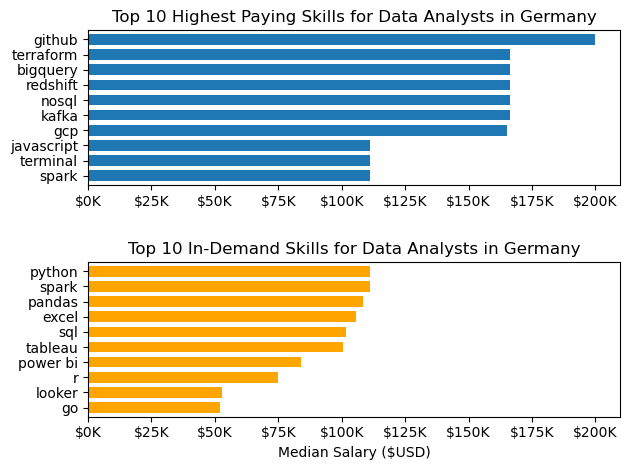

In [60]:
fig, ax = plt.subplots(2, 1)

df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False, width=0.7)
df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False, width=0.7, color='orange')

ax[0].set_title('Top 10 Highest Paying Skills for Data Analysts in Germany')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[1].set_title('Top 10 In-Demand Skills for Data Analysts in Germany')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[1].set_xlim(ax[0].get_xlim())
fig.tight_layout()

fig.subplots_adjust(hspace=0.5)
plt.show()